# Week 3: Advanced Data Analysis, Statistical Validation & Feature Engineering
## AnalystLab Africa — Data Science Internship
### Project: Heart Disease Prediction


### 1. Project Continuity

**Business problem:** ABC Health / AnalystLab Africa Consulting has been asked to help a healthcare provider identify patients at elevated risk of heart disease so they can receive earlier clinical screening and intervention.

**Week 2:** 

Cholesterol initially showed no null values. However, after checking the number of zeroes, we suspected that some of them were missing values recorded as 0. To address this, rows with 0 were converted to NaN (null values), and the missing values were replaced with the column median. The median was used because it is less affected by extreme values and outliers.

The same approach was applied to the RestingBP column.

**Feature Encoding**
Label encoding
Binary categorical variables such as 'Sex' and 'ExerciseAngina' have no natural order (for example, M/F or Yes/No), so label encoding is sufficient and avoids adding extra dimensions.

One-hot encoding was used for categorical variables without a natural order. This avoids implying a false ordinal relationship, which label encoding would introduce.

**Feature Scaling**
StandardScaler is appropriate for this project because it puts numeric columns such as Age, RestingBP, Cholesterol, MaxHR, and OldPeak on the same scale by giving them a mean of 0 and a standard deviation of 1. 


**Target variable:** HeartDisease (binary: 1 = heart disease present, 0 = absent).

### Loading and Inspection of datasets

In [56]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [57]:
#loading the datasets
df = pd.read_csv('OneDrive/Documents/AnalystLab Africa/cleaned_dataset.csv')

In [58]:
# first 5 rows of the data
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 97.6 KB


In [60]:
#checking for null values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## PART 2: ADVANCED EXPLORATORY DATA ANALYSIS

### 2.1 Numerical Distributions & Skewness

This builds on the Week 2 progress of single-variable analysis. Diving deeper to analyze multivariate structures

Age skewness: -0.20
RestingBP skewness: 0.61
Cholesterol skewness: 1.45
MaxHR skewness: -0.14
Oldpeak skewness: 1.02


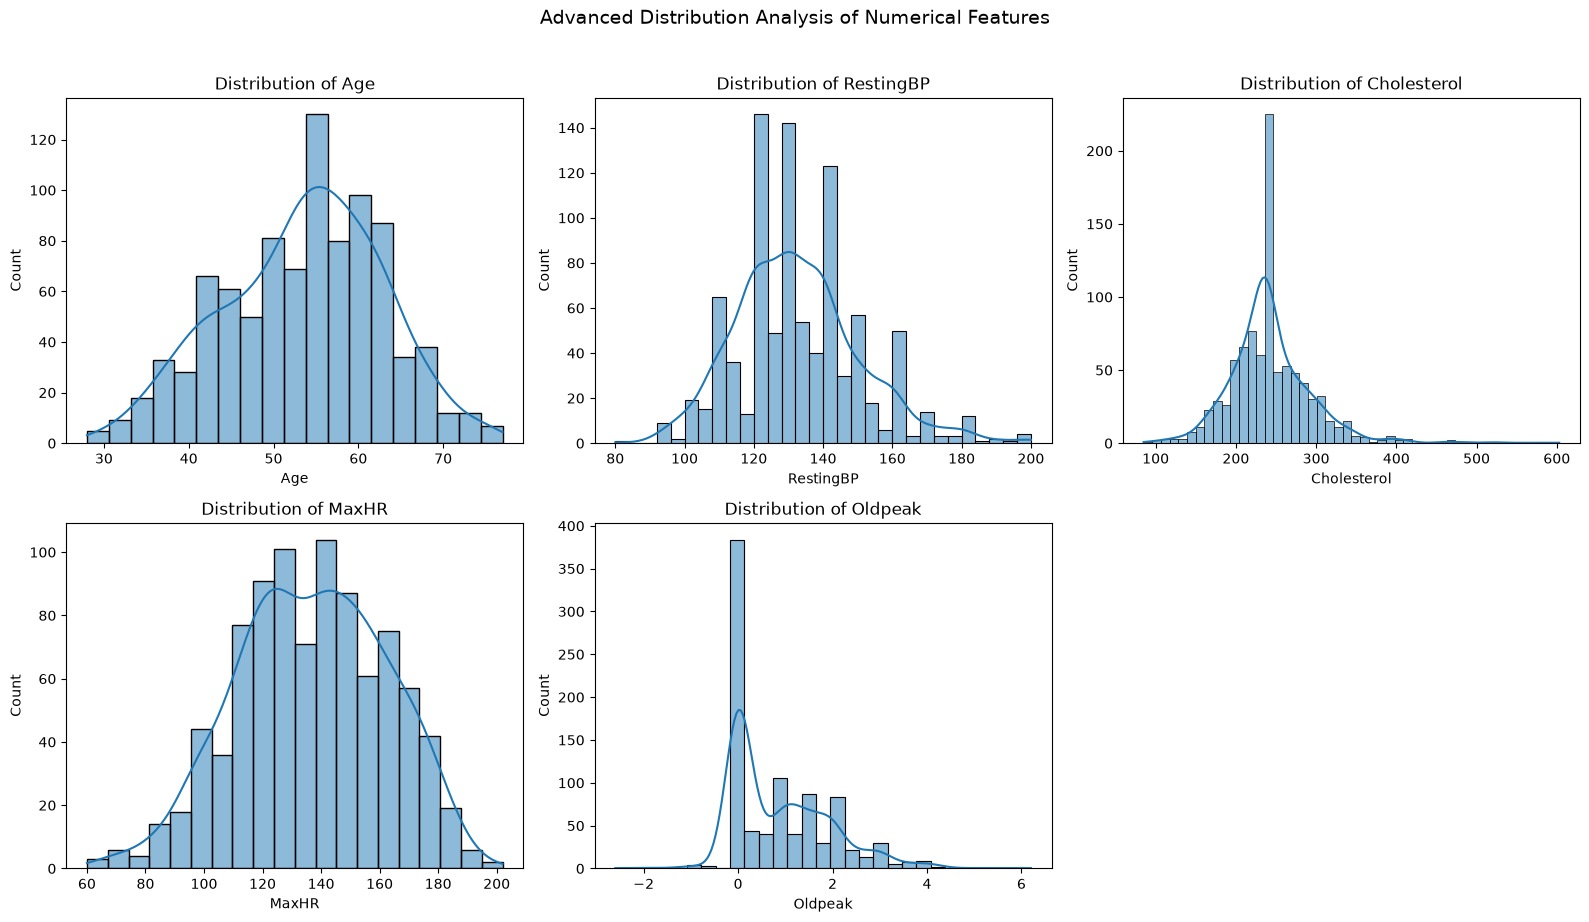

In [61]:
# Distribution and skewness

num_cols = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    print(f"{col} skewness: {df[col].skew():.2f}")
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.suptitle('Advanced Distribution Analysis of Numerical Features', fontsize=14, y=1.02)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Insights**: The numeric features show different distribution shapes, with Age and MaxHR fairly balanced, while RestingBP, Cholesterol, and Oldpeak are right-skewed, indicating a concentration of lower values with a few high outliers.

### 2.2 Numeric Features vs Target (Violin Plots)

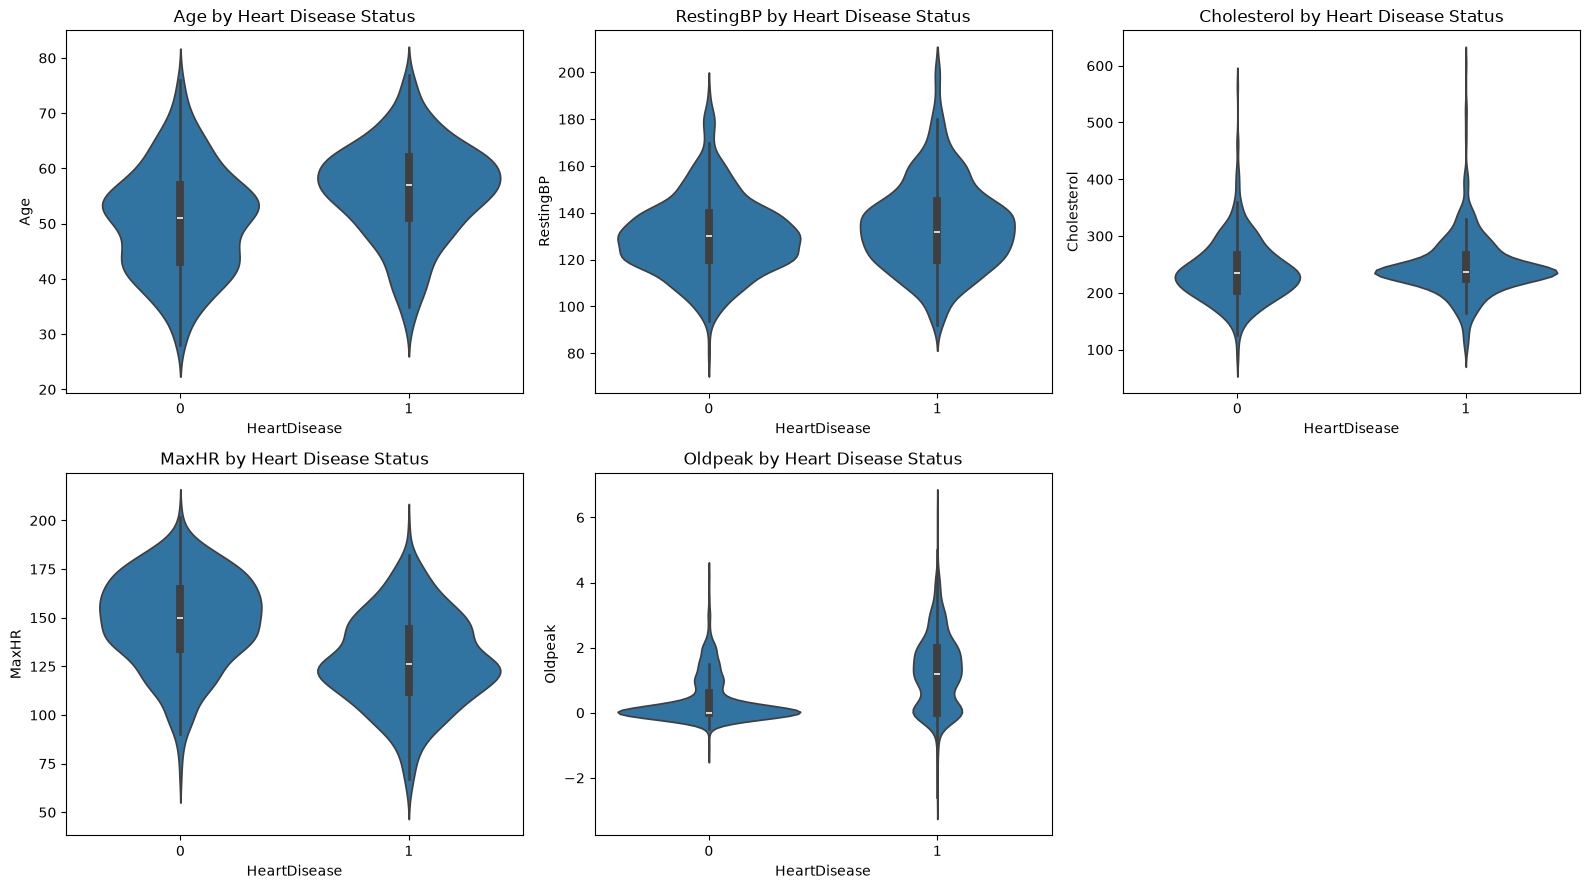

In [62]:
# Numeric vs target variable

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(x='HeartDisease', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} by Heart Disease Status')
    axes[i].set_xlabel('HeartDisease')
    axes[i].set_ylabel(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Insights**: Age, MaxHR, and Oldpeak show clearer separation between heart disease groups, with affected patients tending to be older, have lower MaxHR, and higher Oldpeak, while RestingBP and Cholesterol overlap more and appear less discriminative.

### 2.3 Categorical Features vs Target

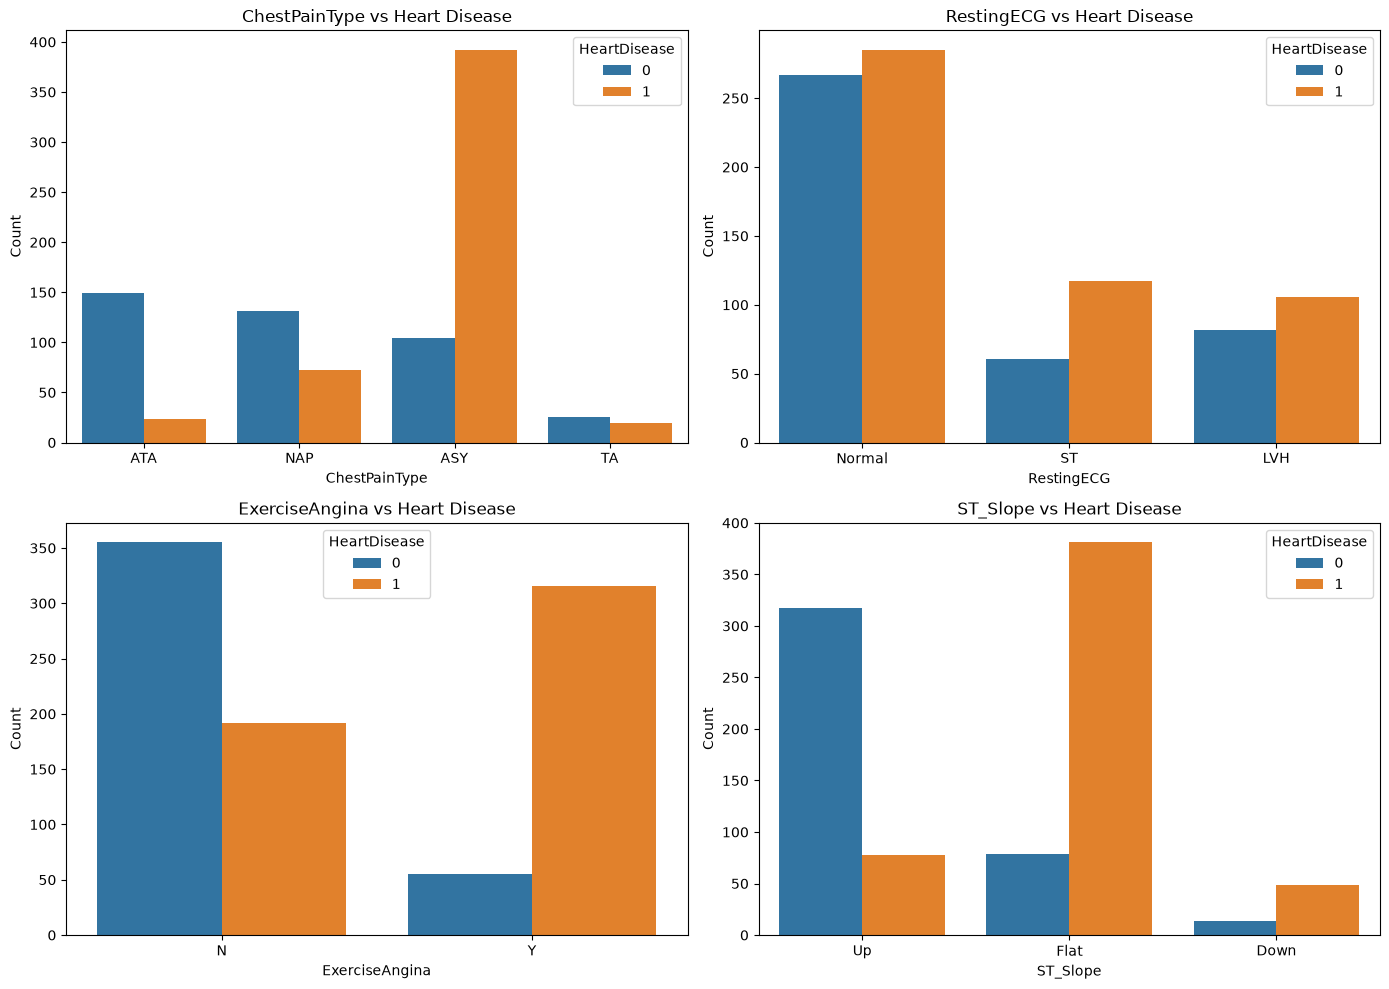

In [63]:
# Categorical vs target variable
cat_cols = ['ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='HeartDisease', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Heart Disease')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Insights**: ChestPainType, ExerciseAngina, and ST_Slope show stronger association with heart disease, while RestingECG shows more mixed overlap, suggesting it is a weaker predictor compared with the other categorical features.

### 2.4 Multivariate Relationship — Age, Cholesterol, Disease, Sex

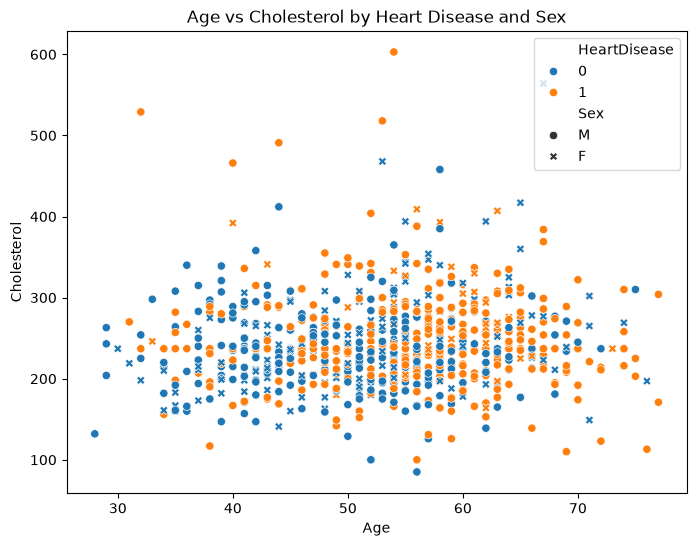

In [64]:
# Multivariate scatter plot

plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Cholesterol', hue='HeartDisease', style='Sex', data=df)
plt.title('Age vs Cholesterol by Heart Disease and Sex')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.show()

**Insights**: Age, Cholesterol, and Sex show only modest separation by heart disease status in this scatter plot, suggesting a weaker multivariate pattern than the earlier bivariate charts.


### 2.5 Correlation Heatmap

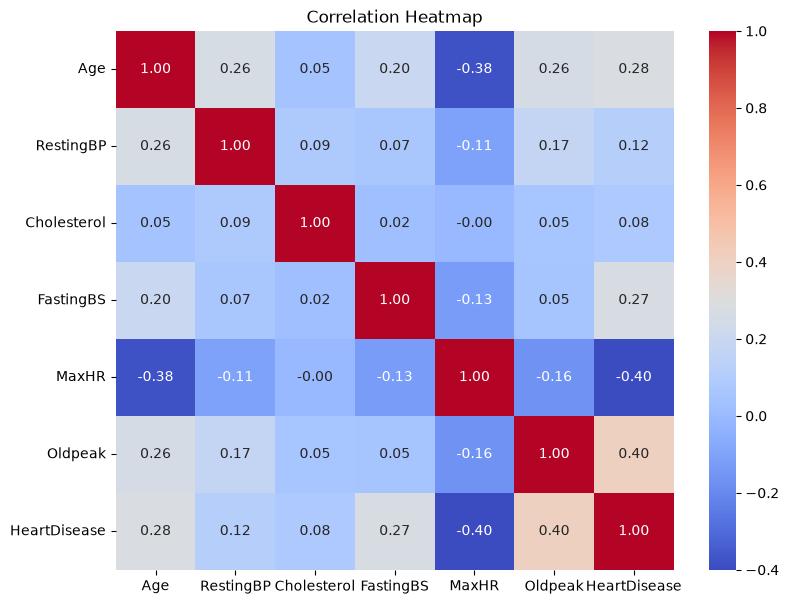

In [65]:
# correlation heat map
plt.figure(figsize=(9,7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Insights**: The heatmap shows that HeartDisease has the strongest relationships with ST_Slope, ExerciseAngina, and Oldpeak, while Age and MaxHR also show noticeable correlations, and the other variables are comparatively weaker.

### 2.6 Pair Plot

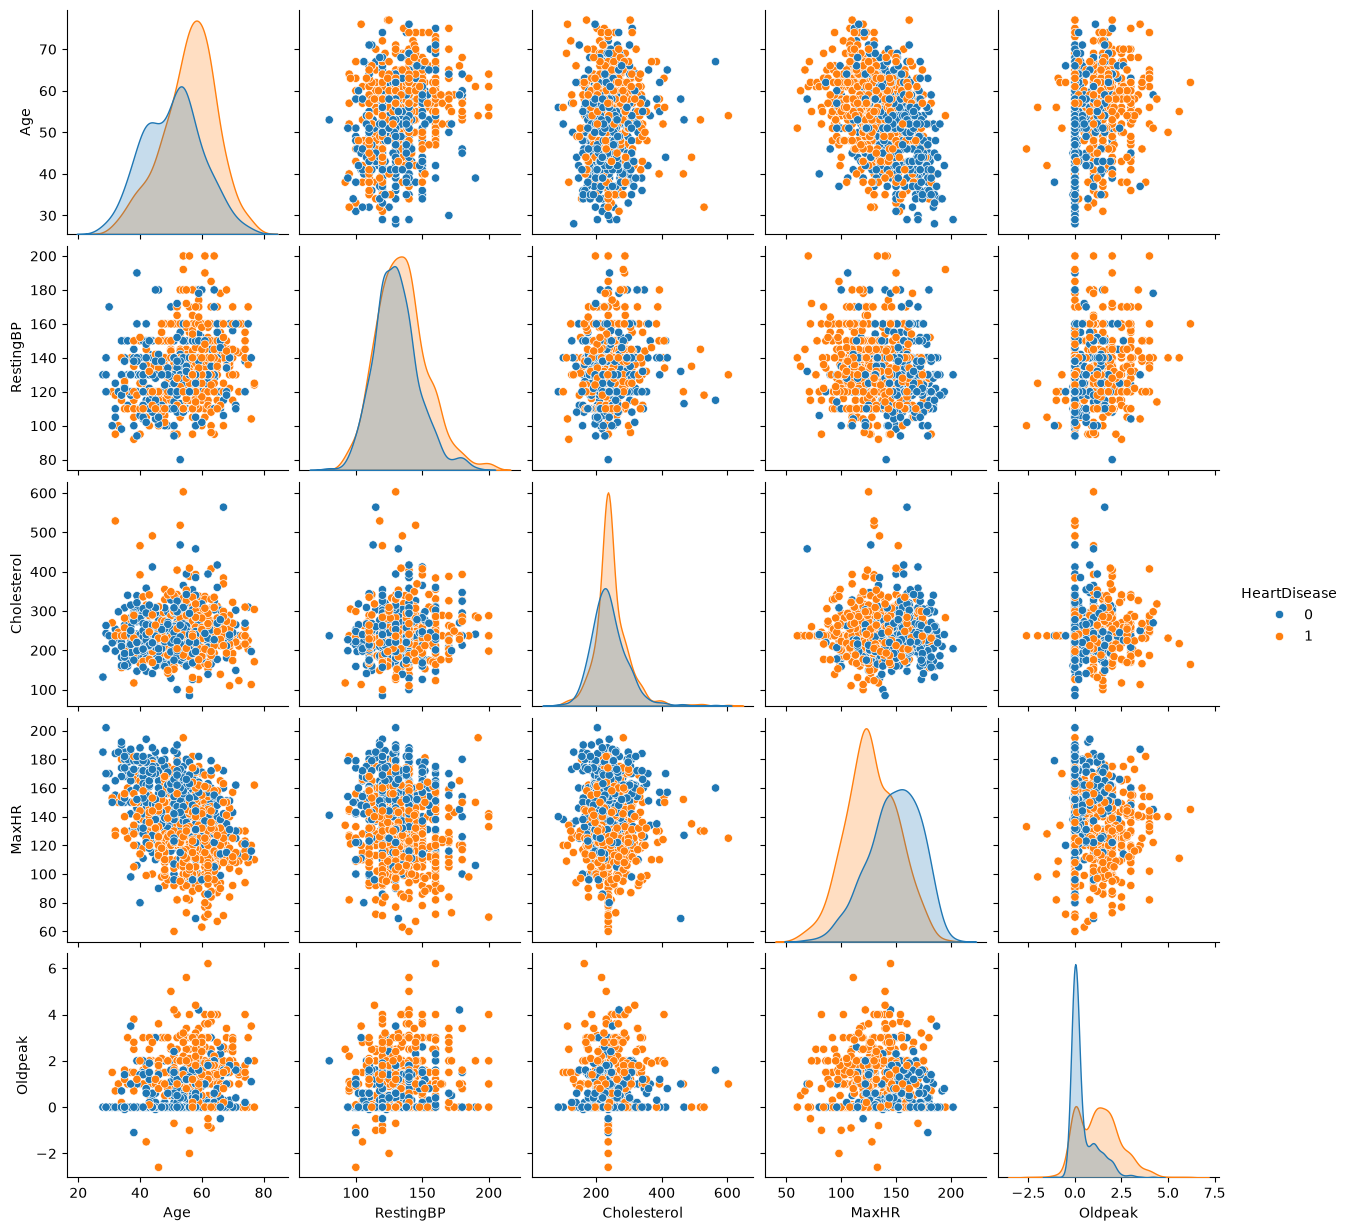

In [66]:
sns.pairplot(df[num_cols + ['HeartDisease']], hue='HeartDisease')
plt.show()

## 3: Statistical Analysis 

Four hypothesis tests are performed below, each following the required structure: business question, objective, H₀, H₁, method, justification, test statistic, p-value, decision, interpretation, and business implication.

### Test 1 — Welch's Independent t-test: MaxHR by HeartDisease

**Business question**: Does maximum heart rate achieved during exercise differ between patients with and without heart disease? **H₀**: Mean MaxHR is equal across groups. **H₁**: Mean MaxHR differs across groups. **Method**: Welch's t-test (does not assume equal variances); Shapiro-Wilk test run first to check normality assumption.

In [67]:
g0 = df[df['HeartDisease']==0]['MaxHR']
g1 = df[df['HeartDisease']==1]['MaxHR']

print("Shapiro-Wilk (No Disease):", stats.shapiro(g0))
print("Shapiro-Wilk (Disease):", stats.shapiro(g1))

t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
print(f"\nWelch's t-test: t = {t_stat:.3f}, p = {p_val:.6f}")
print(f"Mean MaxHR — No Disease: {g0.mean():.2f}, Disease: {g1.mean():.2f}")

Shapiro-Wilk (No Disease): ShapiroResult(statistic=np.float64(0.9822157156816085), pvalue=np.float64(6.238449137848519e-05))
Shapiro-Wilk (Disease): ShapiroResult(statistic=np.float64(0.9961303550607703), pvalue=np.float64(0.25183857587774716))

Welch's t-test: t = 13.231, p = 0.000000
Mean MaxHR — No Disease: 148.15, Disease: 127.66


**Decision:** p < 0.000001 → reject H₀.  
**Interpretation:** Patients without heart disease have a notably higher mean MaxHR (148.15 bpm) than those with heart disease (127.66 bpm).  
**Business implication:** Lower maximum heart rate during exercise testing is strongly associated with heart disease presence, supporting its value as a predictive feature.  

### Test 2 — Chi-Square Test: ChestPainType vs HeartDisease

**Business question:** Is chest pain type associated with heart disease presence?  
**H₀:** ChestPainType and HeartDisease are independent.  
**H₁:** They are associated.  
**Method:** Chi-Square test of independence — appropriate for two categorical variables. 

In [68]:
contingency = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
print(contingency)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi2 = {chi2:.3f}, dof = {dof}, p = {p_val:.6f}")

HeartDisease     0    1
ChestPainType          
ASY            104  392
ATA            149   24
NAP            131   72
TA              26   20

Chi2 = 268.067, dof = 3, p = 0.000000


**Decision:**  p < 0.000001 → reject H₀.    
**Interpretation:**  A strong association exists. Asymptomatic (ASY) patients show 392 of 496 (79%) disease-positive, while Atypical Angina (ATA) patients show only 24 of 173 (14%) disease-positive.    
**Business implication:** Absence of chest pain should not be used to rule out heart disease risk — a clinically significant and counterintuitive finding for screening protocols.  

### Test 3 — Mann-Whitney U Test: Cholesterol by ExerciseAngina

**Business question:** Does cholesterol level differ between patients with and without exercise-induced angina? **H₀:** Cholesterol distribution is the same across groups. **H₁:** Distributions differ.   
**Method:** Non-parametric Mann-Whitney U test, chosen due to Cholesterol's confirmed right skew (1.447) from Deliverable 2.




In [69]:
ga = df[df['ExerciseAngina']=='Y']['Cholesterol']
gb = df[df['ExerciseAngina']=='N']['Cholesterol']

u_stat, p_val = stats.mannwhitneyu(ga, gb)
print(f"U = {u_stat:.1f}, p = {p_val:.6f}")
print(f"Median Cholesterol — Angina Y: {ga.median():.1f}, Angina N: {gb.median():.1f}")

U = 112811.0, p = 0.003882
Median Cholesterol — Angina Y: 237.0, Angina N: 237.0


**Decision:** p = 0.0039 → reject H₀ (statistically significant), though medians are identical (237 in both groups).   
**Interpretation:** Statistically significant but practically weak — a case where significance does not imply strong effect size, likely driven by distribution shape rather than a large median shift.   
**Business implication:** Cholesterol alone may be a weaker discriminator for ExerciseAngina status than other clinical measurements.  

### Test 4 — One-Way ANOVA: MaxHR across ST_Slope categories

**Business question:** Does maximum heart rate differ across ST segment slope categories (Up/Flat/Down)? **H₀:** Mean MaxHR is equal across all ST_Slope groups. **H₁:** At least one group differs.   
**Method:** One-way ANOVA — appropriate for comparing a continuous variable across 3+ independent groups.  

In [70]:
groups = [df[df['ST_Slope']==s]['MaxHR'] for s in df['ST_Slope'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

print(f"F = {f_stat:.3f}, p = {p_val:.6f}")
for s in df['ST_Slope'].unique():
    subset = df[df['ST_Slope']==s]
    print(f"  {s}: mean MaxHR = {subset['MaxHR'].mean():.2f}, n = {len(subset)}")

F = 79.033, p = 0.000000
  Up: mean MaxHR = 148.04, n = 395
  Flat: mean MaxHR = 128.11, n = 460
  Down: mean MaxHR = 129.94, n = 63


**Decision:** p < 0.000001 → reject H₀.   
**Interpretation:** "Up" slope patients show markedly higher mean MaxHR (148.04) than "Flat" (128.11) or "Down" (129.94).   
**Business implication:** ST_Slope shows strong group separation, reinforcing its value as a key predictive feature for Week 4 modelling.  

## 4: Feature Engineering

Three features are engineered below, each grounded in findings from the advanced EDA and statistical testing above.

### Feature 1: AgeGroup

**How:** Age binned into clinically meaningful bands (<40, 40-55, 55-70, 70+).   
**Why:** Delivera hinted at non-linear age effects; binning tests this directly.    
**Business meaning:** Age bands are more interpretable to non-technical stakeholders than raw continuous age.  

In [71]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,40,55,70,100], labels=['<40','40-55','55-70','70+'])

print(df['AgeGroup'].value_counts())
print("\nDisease rate by AgeGroup:")
print(df.groupby('AgeGroup', observed=True)['HeartDisease'].mean().round(3))

AgeGroup
40-55    419
55-70    382
<40       93
70+       24
Name: count, dtype: int64

Disease rate by AgeGroup:
AgeGroup
<40      0.344
40-55    0.451
55-70    0.709
70+      0.667
Name: HeartDisease, dtype: float64


**Insight:** Disease rate rises from 34.4% (<40) to 70.9% (55-70), confirming a strong age-related risk gradient with potential value for Week 4 modelling and stakeholder communication

### Feature 2: Chol_Age_Ratio

**How:** Cholesterol divided by Age.   
**Why:** Tests whether cholesterol relative to age carries more signal than either variable alone.   
**Business meaning:** A normalized risk indicator adjusting cholesterol for age-related baseline changes.  

In [72]:
df['Chol_Age_Ratio'] = df['Cholesterol'] / df['Age']
print(df['Chol_Age_Ratio'].describe())

count    918.000000
mean       4.693778
std        1.373568
min        1.486842
25%        3.822581
50%        4.430354
75%        5.306818
max       16.531250
Name: Chol_Age_Ratio, dtype: float64


### Feature 3: RiskScore

**How:** Composite score (0–3) summing ExerciseAngina presence, FastingBS positivity, and above-median Oldpeak.   
**Why:** Combines three statistically significant clinical indicators (per Deliverable 3) into a single interpretable score.  
**Business meaning:** A simple, clinically intuitive composite risk indicator.  



In [73]:
df['RiskScore'] = (
    (df['ExerciseAngina'].map({'Y':1,'N':0})) +
    (df['FastingBS']) +
    (df['Oldpeak'] > df['Oldpeak'].median()).astype(int)
)

print(df['RiskScore'].value_counts().sort_index())
print("\nDisease rate by RiskScore:")
print(df.groupby('RiskScore')['HeartDisease'].mean().round(3))

RiskScore
0    321
1    241
2    278
3     78
Name: count, dtype: int64

Disease rate by RiskScore:
RiskScore
0    0.193
1    0.564
2    0.845
3    0.962
Name: HeartDisease, dtype: float64


**Insight**: This is the standout engineered feature — disease rate climbs from 19.3% (score 0) to 96.2% (score 3), and its correlation with the target outperforms every original feature

## 5: Feature Evaluation and Selection Summary

Original and engineered numeric features are evaluated for target correlation and multicollinearity (VIF).

In [74]:
numeric_df = df.select_dtypes(include=np.number)
corr_target = numeric_df.corr()['HeartDisease'].sort_values(ascending=False)
print("Correlation with HeartDisease:")
print(corr_target.round(3))

Correlation with HeartDisease:
HeartDisease      1.000
RiskScore         0.577
Oldpeak           0.404
Age               0.282
FastingBS         0.267
RestingBP         0.118
Cholesterol       0.076
Chol_Age_Ratio   -0.114
MaxHR            -0.400
Name: HeartDisease, dtype: float64


In [75]:
 # VIF — constant term included for a statistically valid result
X = numeric_df.drop(columns=['HeartDisease']).dropna()
X_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data['feature'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif_data[vif_data['feature'] != 'const'].round(2))

          feature    VIF
1             Age   9.93
2       RestingBP   1.10
3     Cholesterol  12.68
4       FastingBS   1.74
5           MaxHR   1.31
6         Oldpeak   2.17
7  Chol_Age_Ratio  20.28
8       RiskScore   3.22


**Decisions:**

**Retain RiskScore** — strongest target correlation (0.577) of any feature, original or engineered.    
**Retain** Age, Oldpeak, MaxHR, FastingBS, RestingBP — meaningful target correlation and acceptable VIF.   
**Flag Chol_Age_Ratio for removal** — VIF of ~20 indicates real multicollinearity with its own source variables (Age, Cholesterol), and its target correlation (-0.114) is weak. Since it is mathematically derived from two already-retained features, it adds redundancy without proportional value.   
**Retain Cholesterol8** despite elevated VIF — it is clinically meaningful on its own, and its VIF is partly inflated by the ratio feature above.   

## 6: Dataset Refinement 

In [76]:
#dropping Chol_Age_Ratio per decisions above
final_df = df.drop(columns=['Chol_Age_Ratio'])

In [77]:
print("Final modelling dataset shape:", final_df.shape)
print("\nFinal columns:", list(final_df.columns))

final_df.to_csv('final_modelling_dataset.csv', index=False)
print("\nSaved to final_modelling_dataset.csv")

Final modelling dataset shape: (918, 14)

Final columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'AgeGroup', 'RiskScore']

Saved to final_modelling_dataset.csv
